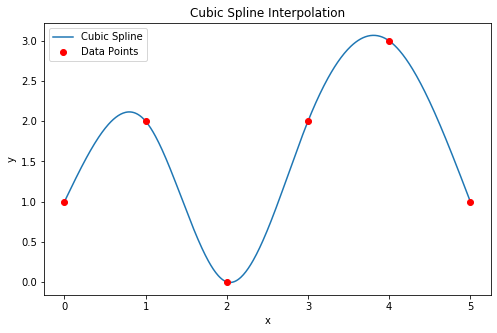

Second derivatives M:
[ 0.         -6.57416268  8.29665072 -2.61244019 -3.84688995  0.        ]


In [6]:
# Mrinal Pradhan
# Homework 6

import numpy as np
import matplotlib.pyplot as plt


def thomas_algorithm(a, b, c, d):
    n = len(d)
    # Make copies so original arrays are not changed
    ac = np.array(a, dtype=float)
    bc = np.array(b, dtype=float)
    cc = np.array(c, dtype=float)
    dc = np.array(d, dtype=float)

    # Forward elimination
    for i in range(1, n):
        factor = ac[i] / bc[i - 1]
        bc[i] = bc[i] - factor * cc[i - 1]
        dc[i] = dc[i] - factor * dc[i - 1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = dc[-1] / bc[-1]

    for i in range(n - 2, -1, -1):
        x[i] = (dc[i] - cc[i] * x[i + 1]) / bc[i]

    return x


def cubic_spline_coefficients(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    n = len(x)

    if n < 3:
        raise ValueError("Need at least 3 data points.")

    # Step 2: interval sizes
    h = np.diff(x)

    # Build tridiagonal system for interior points
    m = n - 2  #
    a = np.zeros(m)
    b = np.zeros(m)
    c = np.zeros(m)
    d = np.zeros(m)

    for i in range(1, n - 1):
        row = i - 1
        if row > 0:
            a[row] = h[i - 1]
        b[row] = 2 * (h[i - 1] + h[i])
        if row < m - 1:
            c[row] = h[i]
        d[row] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    # Solve for interior second derivatives
    M = np.zeros(n)
    if m > 0:
        M[1:n - 1] = thomas_algorithm(a, b, c, d)

    return M


def evaluate_spline(x, y, M, x_eval):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    # Find interval containing x_eval
    if x_eval <= x[0]:
        i = 0
    elif x_eval >= x[-1]:
        i = len(x) - 2
    else:
        i = np.searchsorted(x, x_eval) - 1

    h = x[i + 1] - x[i]

    term1 = M[i] * (x[i + 1] - x_eval) ** 3 / (6 * h)
    term2 = M[i + 1] * (x_eval - x[i]) ** 3 / (6 * h)
    term3 = (y[i] - M[i] * h ** 2 / 6) * (x[i + 1] - x_eval) / h
    term4 = (y[i + 1] - M[i + 1] * h ** 2 / 6) * (x_eval - x[i]) / h

    return term1 + term2 + term3 + term4


# Example data points
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([1, 2, 0, 2, 3, 1], dtype=float)

# Step 3: compute second derivatives
M = cubic_spline_coefficients(x, y)

# Step 4: evaluate spline at many points
x_fine = np.linspace(x[0], x[-1], 500)
y_fine = np.array([evaluate_spline(x, y, M, val) for val in x_fine])

# Step 5: plot results
plt.figure(figsize=(8, 5))
plt.plot(x_fine, y_fine, label="Cubic Spline")
plt.plot(x, y, "ro", label="Data Points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cubic Spline Interpolation")
plt.legend()
plt.show()

# Print second derivatives
print("Second derivatives M:")
print(M)